# Creating Custom Scatterers: Actin and Microtubuli

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import deeptrack as dt

# Depending on your installed version of Deeptrack, you might have to exchange
# the next line for "from deeptrack import units_registry as u"
from deeptrack import units as u
from deeptrack.backend.units import ConversionTable

In [2]:
class Actin(dt.Scatterer):
    __conversion_table__ = ConversionTable(
        radius=(u.meter, u.meter),
        length=(u.meter, u.meter),
        rotation=(u.radian, u.radian),
    )

    def __init__(
            self,
            radius=3.5e-9,
            length=1e-6,
            rotation=(0, 0, 0),
            refractive_index=1.57,
            **kwargs
        ):
        super().__init__(
            radius=radius,
            length=length,
            rotation=rotation,
            refractive_index=refractive_index,
            **kwargs
        )

    def _process_properties(self, properties):
        properties = super()._process_properties(properties)

        # Ensure radius is of length 1
        radius = np.array(properties["radius"])
        if radius.ndim == 0:
            radius = np.array((properties["radius"]))
        elif radius.size == 1:
            radius = np.array((*radius,))
        else:
            radius = radius[:1]
        properties["radius"] = radius

        # Ensure length is scalar
        properties["length"] = float(properties["length"])

        # Ensure rotation is 3 values
        rotation = np.array(properties["rotation"])
        if rotation.ndim == 0:
            rotation = [rotation, 0, 0]
        elif rotation.size == 1:
            rotation = [rotation[0], 0, 0]
        elif rotation.size == 2:
            rotation = [rotation[0], rotation[1], 0]
        properties["rotation"] = tuple(rotation)

        return properties

    def get(
        self,
        *ignore,
        radius,
        length,
        rotation,
        voxel_size,
        **kwargs
    ):

        # Determine grid size
        rad_ceil = np.ceil(radius / np.min(voxel_size[:2]))
        len_ceil = np.ceil(length * 0.5 / voxel_size[2])
        ceil = int(max(rad_ceil, len_ceil))

        # Create grid
        x = np.arange(-ceil, ceil) * voxel_size[0]
        y = np.arange(-ceil, ceil) * voxel_size[1]
        z = np.arange(-ceil, ceil) * voxel_size[2]
        Y, X, Z = np.meshgrid(y, x, z)

        # Rotate the grid
        cos = np.cos(rotation)
        sin = np.sin(rotation)
        XR = (
            cos[0] * cos[1] * X
            + (cos[0] * sin[1] * sin[2] - sin[0] * cos[2]) * Y
            + (cos[0] * sin[1] * cos[2] + sin[0] * sin[2]) * Z
        )
        YR = (
            sin[0] * cos[1] * X
            + (sin[0] * sin[1] * sin[2] + cos[0] * cos[2]) * Y
            + (sin[0] * sin[1] * cos[2] - cos[0] * sin[2]) * Z
        )
        ZR = (-sin[1] * X) + cos[1] * sin[2] * Y + cos[1] * cos[2] * Z

        # Cylinder mask
        mask = ((XR**2 / radius ** 2 + ZR**2 / radius ** 2) < 1) & (
            np.abs(YR) < length / 2
        )

        return mask.astype(float)

In [3]:
actin = Actin(
    position=lambda: np.random.uniform(5, 27, 2),
    # rotation=lambda: np.random.uniform(0, np.pi * 0.2, 2),
    length=2e-6,
)

optics = dt.Fluorescence(
    output_region=(0, 0, 32, 32),
    # resolution=2e-7,
    )

pip = optics(actin ^ 3)

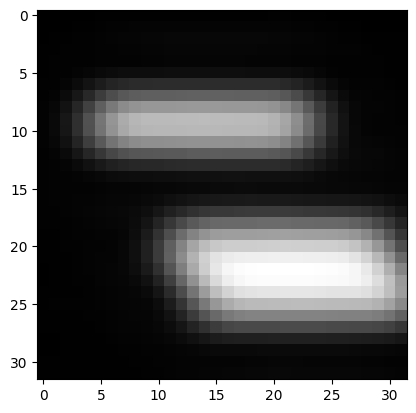

In [4]:
pip.update()
image = pip.resolve()
plt.imshow(image, cmap='gray');

microtuble
- refractive index = 2.8
- diameter = 25nm

actin
- refractive index = 1.57
- diameter = 7 nm
- two strands, twisted around each other. Maybe good enough as a cylinder?


In [5]:
stripe = dt.Ellipse(
    position = lambda: np.random.uniform(5, 123, 2),
    radius=(0.025, 0.5) * dt.units.um
) 

stripes = stripe ^ 5

optics = dt.Fluorescence()

pip = optics(stripes) >> dt.ElasticTransformation(alpha=10, sigma=4)

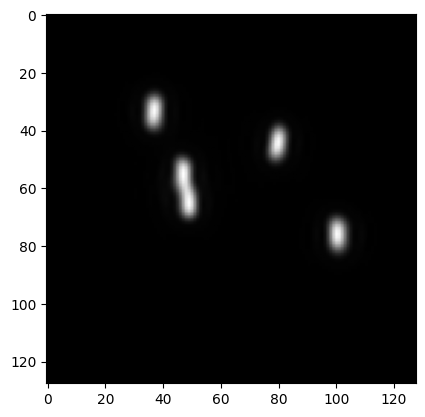

In [6]:
pip.update()

im = pip.resolve()

plt.imshow(im, cmap='gray')